# Hybrid Page Extractor — Legend/Figure Walkthrough

This notebook walks through the hybrid ADE + Google OCR workflow step by step. We reuse the production helpers from `hybrid_page_extractor.py`, `utils_ade.py`, and `utils_ade_official.py` to:

1. Load page structure and text sources.
2. Inspect and visualise ADE chunk categories.
3. Extract legend indicators (even when embedded inside figure-labelled chunks).
4. Find the same indicators inside figure/architectural regions.
5. Overlay all highlights for rapid visual verification.


In [ ]:
from pathlib import Path
from typing import Dict, List, Optional

import fitz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import toml
from IPython.display import display
from matplotlib.patches import Rectangle

from hybrid_page_extractor import extract_page_sources, normalize_document_ai_config
from utils_ade import get_ade_fence_boxes
from utils_ade_official import (
    extract_legend_keywords_and_indicators,
    find_indicators_in_figures,
    filter_ocr_by_ade_regions,
)

plt.rcParams["figure.dpi"] = 144
pd.set_option("display.max_rows", 60)
pd.set_option("display.max_columns", None)


✅ Comprehensive text extraction available


In [ ]:
SECRETS_PATH = Path(".streamlit/secrets.toml")
if not SECRETS_PATH.exists():
    raise FileNotFoundError("Expected .streamlit/secrets.toml with API keys.")

secrets = toml.load(SECRETS_PATH)

ADE_API_KEY = secrets.get("LANDINGAI_API_KEY")
if not ADE_API_KEY:
    raise ValueError("Missing LANDINGAI_API_KEY in secrets.toml")

PDF_PATH = Path("subset_gold/selected_pages_no_annotations.pdf")
PAGE_NUMBER = 2  # change here to inspect a different page

raw_doc_ai_config: Optional[Dict] = None
if "google_cloud" in secrets and "gcp_service_account" in secrets:
    raw_doc_ai_config = {
        "project_number": secrets["google_cloud"].get("project_number"),
        "location": secrets["google_cloud"].get("location"),
        "processor_id": secrets["google_cloud"].get("processor_id"),
        "service_account_info": dict(secrets["gcp_service_account"]),
    }
    doc_ai_config = normalize_document_ai_config(raw_doc_ai_config)
else:
    doc_ai_config = None
    print("⚠️ Google Cloud credentials missing; OCR results will be empty.")

pdf_doc = fitz.open(str(PDF_PATH))
page_index = PAGE_NUMBER - 1
if page_index < 0 or page_index >= len(pdf_doc):
    raise IndexError(f"Page {PAGE_NUMBER} out of bounds for document with {len(pdf_doc)} pages")

pdf_page = pdf_doc[page_index]
page_width = float(pdf_page.rect.width)
page_height = float(pdf_page.rect.height)

print(f"PDF: {PDF_PATH} → {len(pdf_doc)} pages")
print(f"Inspecting page {PAGE_NUMBER} (0-based index {page_index})")
print(f"Page size: {page_width:.1f} × {page_height:.1f} pts")
if doc_ai_config and doc_ai_config.get("client"):
    print("✅ Document AI client initialised")
else:
    print("⚠️ Document AI client not available")


PDF: subset_gold/selected_pages_no_annotations.pdf → 5 pages
Inspecting page 2 (0-based index 1)
Page size: 2592.0 × 1728.0 pts
✅ Document AI client initialised


E0000 00:00:1763429257.393042  788749 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [ ]:
page_sources = extract_page_sources(
    pdf=PDF_PATH,
    page_number=PAGE_NUMBER,
    ade_api_key=ADE_API_KEY,
    doc_ai_config=doc_ai_config,
)

pdf_words: List[Dict] = page_sources["pdf_words"]
pdf_blocks: List[Dict] = page_sources["pdf_blocks"]
pdf_annotations: List[Dict] = page_sources["pdf_annotations"]
ocr_tokens: List[Dict] = page_sources["ocr_tokens"]
ade_chunks: List[Dict] = page_sources["ade_chunks"]

print("Extraction summary:")
print(f"  PDF words: {len(pdf_words)}")
print(f"  PDF blocks: {len(pdf_blocks)}")
print(f"  PDF annotations: {len(pdf_annotations)}")
print(f"  OCR tokens: {len(ocr_tokens)}")
print(f"  ADE chunks: {len(ade_chunks)}")

with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame(ade_chunks)[["id", "type", "x0", "y0", "x1", "y1", "markdown", "text"]].head(6))


Extraction summary:
  PDF words: 1620
  PDF blocks: 334
  PDF annotations: 0
  OCR tokens: 2011
  ADE chunks: 19


,id,type,x0,y0,x1,y1,markdown,text
0,bb917048-ba53-437c-b1c2-7260c45d9427,figure,136.068051,31.985355,1489.177448,1280.020145,<a id='bb917048-ba53-437c-b1c2-7260c45d9427'></a>\n\n<::A site plan showing an industrial warehouse building and its...,
1,c37dfe36-7705-4f64-96b9-15051c0bf446,table,588.969880,1279.166714,1493.378946,1701.858685,"<a id='c37dfe36-7705-4f64-96b9-15051c0bf446'></a>\n\n<table id=""1-1"">\n<tr><td id=""1-2"" colspan=""3"">KEYNOTES</td></t...",
2,82c77abc-4ae0-483e-b3b9-9d1ed314833e,text,1488.795382,33.355419,1939.974936,255.497892,<a id='82c77abc-4ae0-483e-b3b9-9d1ed314833e'></a>\n\n# PROJECT TEAM\n\n## OWNER / DEVELOPER\nRYAN COMPANIES\n3900 E....,
3,02ee6cbf-ce69-420e-9f62-a0eb7c89646f,text,1488.134605,255.449175,1940.470402,471.657280,<a id='02ee6cbf-ce69-420e-9f62-a0eb7c89646f'></a>\n\n## CITY OF PHOENIX NOTES\n\n* DEVELOPMENT AND USE OF THIS SITE ...,
4,33a4a9b9-82d5-4eb2-b339-e37770150baa,text,1487.131931,471.103363,1941.108467,1156.963348,<a id='33a4a9b9-82d5-4eb2-b339-e37770150baa'></a>\n\n## LEGAL DESCRIPTION\n\nA PORTION OF THE WEST HALF OF SECTION 1...,
5,dd42bf77-047c-4222-a4ad-7dd3d2395192,text,1488.809904,1156.452690,1940.896345,1317.141541,<a id='dd42bf77-047c-4222-a4ad-7dd3d2395192'></a>\n\n# PROJECT DESCRIPTION\n\nSCOPE OF WORK:\nTHIS SUBMITTAL CONSIST...,


In [ ]:
RENDER_DPI = 144
page_pix = pdf_page.get_pixmap(dpi=RENDER_DPI)
page_img = np.frombuffer(page_pix.samples, dtype=np.uint8).reshape(page_pix.height, page_pix.width, page_pix.n)
if page_pix.n == 4:
    page_img = page_img[:, :, :3]

scale_x = page_pix.width / page_width
scale_y = page_pix.height / page_height

print(f"Rendered preview at {RENDER_DPI} DPI → image {page_pix.width}×{page_pix.height}")


def show_page(figsize=(10, 14), title: Optional[str] = None):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(page_img)
    ax.set_axis_off()
    if title:
        ax.set_title(title)
    return fig, ax


def add_boxes(
    ax,
    records: List[Dict],
    color: str,
    label_key: Optional[str] = None,
    linewidth: float = 1.4,
    alpha: float = 0.5,
):
    for rec in records:
        x0 = float(rec.get("x0", 0.0)) * scale_x
        y0 = float(rec.get("y0", 0.0)) * scale_y
        x1 = float(rec.get("x1", 0.0)) * scale_x
        y1 = float(rec.get("y1", 0.0)) * scale_y
        width = max(x1 - x0, 1.0)
        height = max(y1 - y0, 1.0)

        rect = Rectangle((x0, y0), width, height, linewidth=linewidth, edgecolor=color, facecolor=(0, 0, 0, 0))
        rect.set_alpha(alpha)
        ax.add_patch(rect)

        if label_key:
            text = rec.get(label_key)
            if text:
                ax.text(
                    x0,
                    max(y0 - 6, 8),
                    str(text)[:42],
                    color="black",
                    fontsize=8,
                    bbox=dict(facecolor=color, alpha=alpha, edgecolor="none", pad=1.5),
                )


Rendered preview at 144 DPI → image 5184×3456


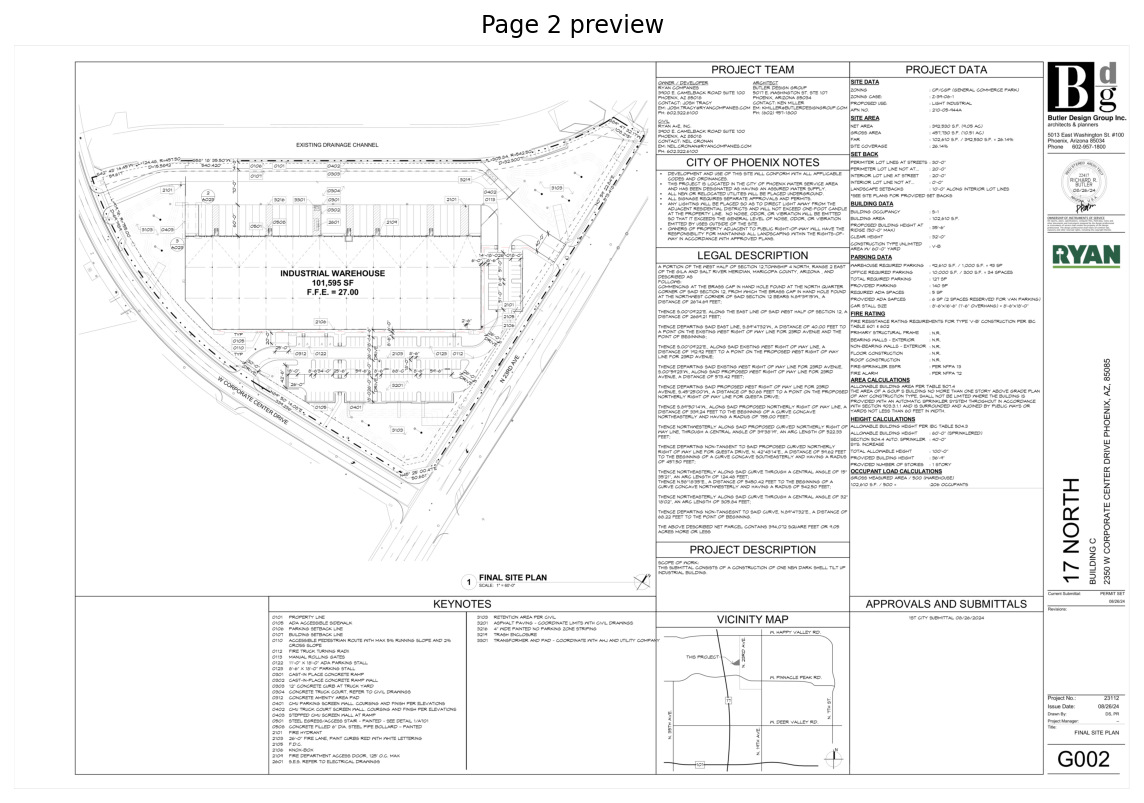

In [ ]:
show_page(title=f"Page {PAGE_NUMBER} preview");


In [ ]:
def chunk_label(chunk: Dict) -> str:
    return (chunk.get("type") or "").lower()

legend_like_chunks = []
figure_chunks = []
other_chunks = []
for chunk in ade_chunks:
    ctype = chunk_label(chunk)
    text_lower = (chunk.get("markdown") or chunk.get("text") or "").lower()
    is_figure = ctype in {"figure", "architectural_drawing"}
    is_logo = ctype == "logo"
    has_legend_hint = "legend" in text_lower or "keynote" in text_lower

    if (not is_figure and not is_logo) or has_legend_hint:
        legend_like_chunks.append(chunk)
    elif is_figure:
        figure_chunks.append(chunk)
    else:
        other_chunks.append(chunk)

print(
    f"Chunk counts → legend-like: {len(legend_like_chunks)}, figure: {len(figure_chunks)}, other: {len(other_chunks)}"
)

with pd.option_context("display.max_colwidth", 90):
    display(pd.DataFrame(legend_like_chunks)[["id", "type", "markdown", "text"]].head(8))


Chunk counts → legend-like: 14, figure: 2, other: 3


,id,type,markdown,text
0,c37dfe36-7705-4f64-96b9-15051c0bf446,table,"<a id='c37dfe36-7705-4f64-96b9-15051c0bf446'></a>\n\n<table id=""1-1"">\n<tr><td id=""1-2...",
1,82c77abc-4ae0-483e-b3b9-9d1ed314833e,text,<a id='82c77abc-4ae0-483e-b3b9-9d1ed314833e'></a>\n\n# PROJECT TEAM\n\n## OWNER / DEVE...,
2,02ee6cbf-ce69-420e-9f62-a0eb7c89646f,text,<a id='02ee6cbf-ce69-420e-9f62-a0eb7c89646f'></a>\n\n## CITY OF PHOENIX NOTES\n\n* DEV...,
3,33a4a9b9-82d5-4eb2-b339-e37770150baa,text,<a id='33a4a9b9-82d5-4eb2-b339-e37770150baa'></a>\n\n## LEGAL DESCRIPTION\n\nA PORTION...,
4,dd42bf77-047c-4222-a4ad-7dd3d2395192,text,<a id='dd42bf77-047c-4222-a4ad-7dd3d2395192'></a>\n\n# PROJECT DESCRIPTION\n\nSCOPE OF...,
5,44deaaf5-c1e7-4f4d-8604-6874ba35b160,text,<a id='44deaaf5-c1e7-4f4d-8604-6874ba35b160'></a>\n\n# PROJECT DATA\n\n## SITE DATA\nZ...,
6,f4356e24-b03b-4d37-bef5-eb91ea054800,text,<a id='f4356e24-b03b-4d37-bef5-eb91ea054800'></a>\n\n## OWNERSHIP OF INSTRUMENTS OF SE...,
7,44f5824e-8ee0-4767-9345-5cdf252522e7,text,<a id='44f5824e-8ee0-4767-9345-5cdf252522e7'></a>\n\n17 NORTH\nBUILDING C\n2350 W CORP...,


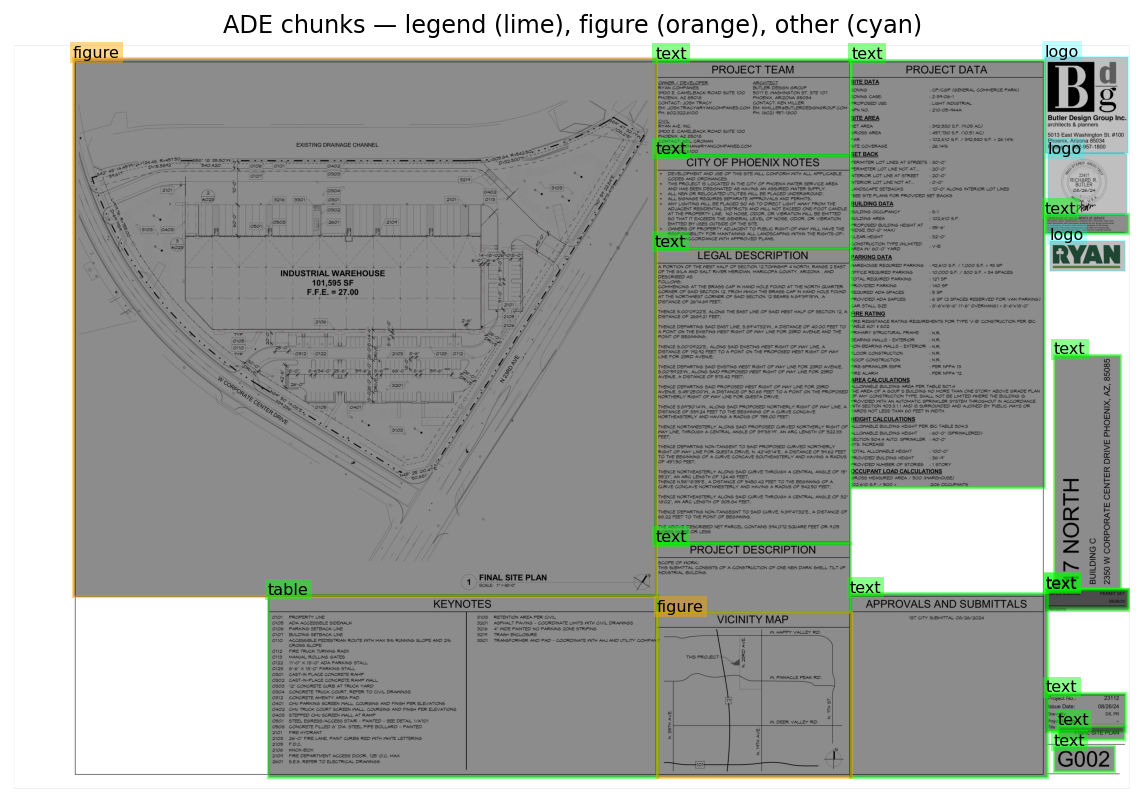

In [ ]:
fig, ax = show_page(title="ADE chunks — legend (lime), figure (orange), other (cyan)")
add_boxes(ax, legend_like_chunks, color="lime", label_key="type", linewidth=1.6, alpha=0.45)
add_boxes(ax, figure_chunks, color="orange", label_key="type", linewidth=1.6, alpha=0.45)
add_boxes(ax, other_chunks, color="cyan", label_key="type", linewidth=1.0, alpha=0.25)
plt.show()


In [ ]:
legend_llm = None
openai_api_key = secrets.get("OPENAI_API_KEY") or secrets.get("openai_api_key")
if openai_api_key:
    try:
        from langchain_openai import ChatOpenAI

        legend_llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0,
            api_key=openai_api_key,
            timeout=180,
            max_retries=2,
        )
        print("✅ Legend LLM initialised (gpt-4o-mini)")
    except Exception as exc:
        print(f"⚠️ Failed to initialise legend LLM: {exc}")
else:
    print("⚠️ OPENAI_API_KEY missing; legend indicator extraction will be skipped.")


✅ Legend LLM initialised (gpt-4o-mini)


In [ ]:
FENCE_KEYWORDS = [
    "fence",
    "fencing",
    "gate",
    "barrier",
    "guardrail",
    "post",
    "mesh",
    "panel",
    "chain link",
    "masonry",
    "bollard",
    "wall",
    "railing",
    "enclosure",
    "perimeter",
    "screen",
    "security",
]

legend_highlights: List[Dict] = []
legend_indicator_records: List[Dict] = []

if legend_llm is None:
    print("⚠️ Legend LLM unavailable → skipping extraction.")
else:
    legend_highlights = extract_legend_keywords_and_indicators(
        page_chunks=legend_like_chunks,
        google_ocr_results=ocr_tokens,
        fence_keywords=FENCE_KEYWORDS,
        page_width=page_width,
        page_height=page_height,
        llm=legend_llm,
        pdf_text_layer_words=pdf_words,
    )
    print(f"Legend indicator highlights: {len(legend_highlights)}")

    for entry in legend_highlights:
        indicator_code = entry.get("indicator_code") or entry.get("text")
        if not indicator_code:
            continue
        legend_indicator_records.append(
            {
                "indicator": str(indicator_code),
                "description": entry.get("description", ""),
                "source": entry.get("source", ""),
                "x0": entry.get("x0"),
                "y0": entry.get("y0"),
                "x1": entry.get("x1"),
                "y1": entry.get("y1"),
            }
        )

legend_highlights_df = pd.DataFrame(legend_highlights)
legend_indicator_df = pd.DataFrame(legend_indicator_records).drop_duplicates(subset=["indicator"], keep="first")

if not legend_indicator_df.empty:
    display(legend_indicator_df.head(12))
else:
    print("No legend indicators recorded.")


Legend indicator highlights: 0
No legend indicators recorded.


In [ ]:
if legend_highlights:
    fig, ax = show_page(title="Legend indicator highlights (dark orange)")
    add_boxes(ax, legend_highlights, color="darkorange", label_key="indicator_code", linewidth=1.6, alpha=0.55)
    plt.show()
else:
    print("No legend highlights to render.")


No legend highlights to render.


In [ ]:
figure_indicator_highlights: List[Dict] = []
if legend_indicator_records and legend_llm is not None:
    indicator_payload = [
        {
            "indicator": rec.get("indicator"),
            "description": rec.get("description", ""),
        }
        for rec in legend_indicator_records
        if rec.get("indicator")
    ]
    if indicator_payload:
        figure_indicator_highlights = find_indicators_in_figures(
            indicators=indicator_payload,
            page_chunks=figure_chunks,
            google_ocr_results=ocr_tokens,
            page_width=page_width,
            page_height=page_height,
            llm=legend_llm,
            fence_keywords=FENCE_KEYWORDS,
        )
        print(f"Figure indicator hits: {len(figure_indicator_highlights)}")
else:
    if not legend_indicator_records:
        print("No legend indicators available to search within figures.")

figure_indicator_df = pd.DataFrame(figure_indicator_highlights)
if not figure_indicator_df.empty:
    display(figure_indicator_df[[col for col in ["text", "indicator_code", "indicator", "x0", "y0", "x1", "y1"] if col in figure_indicator_df.columns]].head(12))
else:
    print("No figure indicators detected.")


No legend indicators available to search within figures.
No figure indicators detected.


In [ ]:
if figure_indicator_highlights:
    fig, ax = show_page(title="Figure hits (magenta) versus legend (dark orange)")
    add_boxes(ax, legend_highlights, color="darkorange", label_key="indicator_code", linewidth=1.6, alpha=0.45)
    add_boxes(ax, figure_indicator_highlights, color="magenta", label_key="indicator_code", linewidth=1.4, alpha=0.65)
    plt.show()
else:
    print("No figure indicator overlay to render.")


No figure indicator overlay to render.


In [ ]:
ade_keyword_boxes = get_ade_fence_boxes(ade_elements=ade_chunks, fence_keywords=FENCE_KEYWORDS, signals=None)
print(f"ADE keyword-driven highlight boxes: {len(ade_keyword_boxes)}")

if ade_keyword_boxes:
    fig, ax = show_page(title="ADE keyword boxes (green)")
    add_boxes(ax, ade_keyword_boxes, color="lime", label_key="text", linewidth=1.2, alpha=0.35)
    plt.show()


ADE keyword-driven highlight boxes: 0


In [ ]:
summary = {
    "legend_chunks": len(legend_like_chunks),
    "figure_chunks": len(figure_chunks),
    "legend_indicators": len(legend_indicator_df),
    "figure_indicator_hits": len(figure_indicator_highlights),
    "ade_keyword_boxes": len(ade_keyword_boxes),
}
summary


{'legend_chunks': 14,
 'figure_chunks': 2,
 'legend_indicators': 0,
 'figure_indicator_hits': 0,
 'ade_keyword_boxes': 0}

In [ ]:
pdf_doc.close()


## Next Steps
- Adjust `PAGE_NUMBER` (or `PDF_PATH`) to inspect different pages.
- If you want to export merged overlays, reuse the routines in `utils_ade.py` / `app_ade.py` that burn highlights back into a PDF.
- When experimenting without Document AI credentials, expect `ocr_tokens` to be empty—the legend indicator extraction will still run on PDF text, but figure hits may be sparse.
